## Segmentation-Guided Brain Tumor Classification Using Refined Tumor ROIs¶

### Goal:
Use refined tumor segmentation masks to extract tumor ROIs and classify tumors into:
- Pituitary
- Glioma

The segmentation model acts as a localization and contour-refinement stage before classification.

### Import Libraries

In [12]:
import os
import cv2
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

from torchvision.models import resnet18

import torch.nn as nn

### Load COCO Annotations

Load the same annotation file:

In [13]:
train_dir = r"C:\Users\HP PC\Downloads\Tumor_segmentation_train"

json_path = os.path.join(
    train_dir,
    "_annotations.coco.json"
)

with open(json_path, "r") as f:

    coco_data = json.load(f)

print("COCO annotations loaded")

COCO annotations loaded


### Build Image → Class Mapping

This is VERY important.

In [14]:
label_map = {
    1: "pituitary",
    2: "glioma"
}

image_class_map = {}

for ann in coco_data["annotations"]:

    image_id = ann["image_id"]

    category_id = ann["category_id"]

    image_class_map[image_id] = category_id

print("Class mapping completed")

Class mapping completed


### Create Classification DataFrame

Now create:

* image path
* label

dataset.

In [15]:
classification_data = []

for img in coco_data["images"]:

    image_id = img["id"]

    file_name = img["file_name"]

    if image_id in image_class_map:

        category_id = image_class_map[image_id]

        image_path = os.path.join(
            train_dir,
            file_name
        )

        classification_data.append({

            "image_path": image_path,

            "label": category_id
        })

df = pd.DataFrame(classification_data)

df.head(10)

,image_path,label
0,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,1
1,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,1
2,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,1
3,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,1
4,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,1
5,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,1
6,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,1
7,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,2
8,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,2
9,C:\Users\HP PC\Downloads\Tumor_segmentation_tr...,1


### Load The Refined Segmentation Model

This notebook must first load your best fine-tuned segmentation weights.

In [16]:
import torch

from monai.networks.nets import AttentionUnet

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Rebuild model
segmentation_model = AttentionUnet(
    spatial_dims=2,
    in_channels=3,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2)
).to(device)

# Load best fine-tuned weights
segmentation_model.load_state_dict(
    torch.load(
        "best_attention_unet_finetuned.pth",
        map_location=device
    )
)

segmentation_model.eval()

print("Refined segmentation model loaded")

Refined segmentation model loaded


### Why This Step Matters

You are NOT training segmentation again.

You are now USING the refined segmentation model as:

a localization engine.

### Create Classification Dataset

Now build:

* image paths
* labels.

In [17]:
import os
import json
import pandas as pd

# Paths
train_dir = r"C:\Users\HP PC\Downloads\Tumor_segmentation_train"

json_path = os.path.join(
    train_dir,
    "_annotations.coco.json"
)

# Load COCO annotations
with open(json_path, "r") as f:

    coco_data = json.load(f)

# Build image -> class mapping
image_class_map = {}

for ann in coco_data["annotations"]:

    image_id = ann["image_id"]

    category_id = ann["category_id"]

    image_class_map[image_id] = category_id

# Create classification records
classification_data = []

for img in coco_data["images"]:

    image_id = img["id"]

    file_name = img["file_name"]

    if image_id in image_class_map:

        classification_data.append({

            "image_path": os.path.join(
                train_dir,
                file_name
            ),

            "label": image_class_map[image_id]
        })

# DataFrame
df = pd.DataFrame(classification_data)

print(df.head())

print("\nTotal samples:", len(df))

                                          image_path  label
0  C:\Users\HP PC\Downloads\Tumor_segmentation_tr...      1
1  C:\Users\HP PC\Downloads\Tumor_segmentation_tr...      1
2  C:\Users\HP PC\Downloads\Tumor_segmentation_tr...      1
3  C:\Users\HP PC\Downloads\Tumor_segmentation_tr...      1
4  C:\Users\HP PC\Downloads\Tumor_segmentation_tr...      1

Total samples: 1501


### Verify Class Balance

In [18]:
print(df["label"].value_counts())

label
1    771
2    730
Name: count, dtype: int64


### Create ROI Save Folder

Very important.

We now create a folder to store:

segmented tumor crops.

In [19]:
roi_dir = "tumor_rois"

os.makedirs(roi_dir, exist_ok=True)

print("ROI folder created")

ROI folder created


### Generate Refined Tumor ROIs

using:

* segmentation masks
* morphology refinement
* contour extraction
* bounding-box cropping.

This is the heart of:

segmentation-assisted classification.

### Create Morphological Refinement Function

Reuse your successful refinement logic.

In [20]:
import cv2
import numpy as np

def refine_mask(pred_mask):

    # Convert to uint8
    mask = (pred_mask * 255).astype(np.uint8)

    # Kernel
    kernel = np.ones((5,5), np.uint8)

    # Opening
    opened = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    # Closing
    closed = cv2.morphologyEx(
        opened,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Largest connected component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        closed,
        connectivity=8
    )

    refined = np.zeros_like(closed)

    if num_labels > 1:

        largest_label = 1 + np.argmax(
            stats[1:, cv2.CC_STAT_AREA]
        )

        refined[labels == largest_label] = 255

    refined = refined / 255.0

    return refined

### Create Image Transform

In [21]:
from torchvision import transforms

transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.Resize((256,256)),

    transforms.ToTensor()
])

### Generate Refined ROIs

This is the MOST important stage.

In [22]:
saved_count = 0

roi_records = []

for idx, row in df.iterrows():

    image_path = row["image_path"]

    label = row["label"]

    # ---------------- LOAD IMAGE ----------------
    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    original = image.copy()

    # Resize for segmentation
    resized = cv2.resize(
        image,
        (256,256)
    )

    # Transform
    input_tensor = transform(resized)

    input_tensor = input_tensor.unsqueeze(0).to(device)

    # ---------------- SEGMENTATION ----------------
    with torch.no_grad():

        output = segmentation_model(input_tensor)

        pred = (
            torch.sigmoid(output) > 0.5
        ).float()

    pred_mask = pred[0][0].cpu().numpy()

    # ---------------- MORPHOLOGY ----------------
    refined_mask = refine_mask(pred_mask)

    # Convert mask
    mask_uint8 = (
        refined_mask * 255
    ).astype(np.uint8)

    # ---------------- FIND CONTOUR ----------------
    contours, _ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # Skip if no contour
    if len(contours) == 0:
        continue

    # Largest contour
    largest_contour = max(
        contours,
        key=cv2.contourArea
    )

    # Bounding box
    x, y, w, h = cv2.boundingRect(
        largest_contour
    )

    # ---------------- CROP ROI ----------------
    roi = resized[y:y+h, x:x+w]

    # Skip tiny crops
    if roi.shape[0] < 20 or roi.shape[1] < 20:
        continue

    # Resize ROI for classification
    roi = cv2.resize(
        roi,
        (224,224)
    )

    # ---------------- SAVE ROI ----------------
    roi_filename = f"roi_{saved_count}.png"

    roi_path = os.path.join(
        roi_dir,
        roi_filename
    )

    cv2.imwrite(
        roi_path,
        cv2.cvtColor(
            roi,
            cv2.COLOR_RGB2BGR
        )
    )

    roi_records.append({

        "roi_path": roi_path,

        "label": label
    })

    saved_count += 1

print("Total ROIs saved:", saved_count)

Total ROIs saved: 1500


### Visualize Saved ROIs

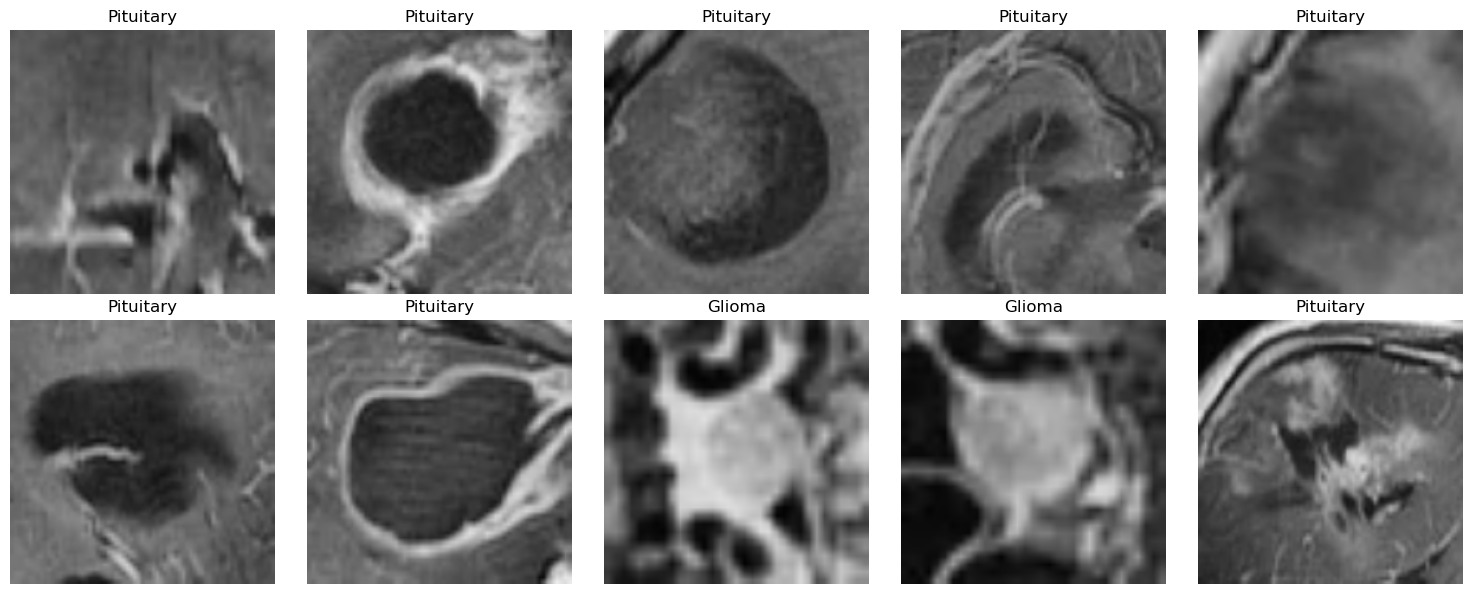

In [23]:
import matplotlib.pyplot as plt
import cv2

# Display first 10 ROIs
num_samples = 10

plt.figure(figsize=(15,6))

for i in range(num_samples):

    roi_path = roi_records[i]["roi_path"]

    label = roi_records[i]["label"]

    image = cv2.imread(roi_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,5,i+1)

    plt.imshow(image)

    if label == 1:
        plt.title("Pituitary")

    elif label == 2:
        plt.title("Glioma")

    plt.axis("off")

plt.tight_layout()

plt.show()

### ROI-Based Tumor Classification

using:

* refined tumor ROIs
* subtype labels
* segmentation-guided preprocessing.

This is now a true:

morphology-aware classification pipeline.

### Create ROI DataFrame

You already created:

roi_records

Now convert it into a DataFrame.

In [24]:
roi_df = pd.DataFrame(roi_records)

print(roi_df.head())

print("\nTotal ROI samples:", len(roi_df))

               roi_path  label
0  tumor_rois\roi_0.png      1
1  tumor_rois\roi_1.png      1
2  tumor_rois\roi_2.png      1
3  tumor_rois\roi_3.png      1
4  tumor_rois\roi_4.png      1

Total ROI samples: 1500


### Convert Labels To Readable Names

In [25]:
label_names = {

    1: "pituitary",

    2: "glioma"
}

roi_df["class_name"] = roi_df["label"].map(
    label_names
)

print(
    roi_df["class_name"].value_counts()
)

class_name
pituitary    771
glioma       729
Name: count, dtype: int64


### Train / Validation Split

In [26]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(

    roi_df,

    test_size=0.2,

    stratify=roi_df["label"],

    random_state=42
)

print("Train samples:", len(train_df))

print("Validation samples:", len(valid_df))

Train samples: 1200
Validation samples: 300


### Create Classification Dataset Class

In [27]:
from torch.utils.data import Dataset
from PIL import Image

class TumorROIDataset(Dataset):

    def __init__(

        self,

        dataframe,

        transform=None
    ):

        self.dataframe = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["roi_path"]
        ).convert("RGB")

        label = row["label"]

        # Convert labels:
        # pituitary=0
        # glioma=1

        if label == 1:

            label = 0

        elif label == 2:

            label = 1

        if self.transform:

            image = self.transform(image)

        return image, label

### Create Classification Transforms

In [28]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor()
])

valid_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor()
])

### Create Datasets + DataLoaders

In [29]:
from torch.utils.data import DataLoader

train_dataset = TumorROIDataset(

    train_df,

    transform=train_transform
)

valid_dataset = TumorROIDataset(

    valid_df,

    transform=valid_transform
)

train_loader = DataLoader(

    train_dataset,

    batch_size=16,

    shuffle=True
)

valid_loader = DataLoader(

    valid_dataset,

    batch_size=16,

    shuffle=False
)

print("Classification DataLoaders ready")

Classification DataLoaders ready


### Load ResNet18 Classifier

In [30]:
from torchvision.models import resnet18

classification_model = resnet18(
    pretrained=True
)

# Replace classifier head
classification_model.fc = nn.Linear(
    classification_model.fc.in_features,
    2
)

classification_model = classification_model.to(device)

print(classification_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

C:\Users\HP PC\.conda\envs\radiomics\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\HP PC\.conda\envs\radiomics\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Define Loss + Optimizer

In [31]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    classification_model.parameters(),

    lr=1e-4
)

print("Classifier ready")

Classifier ready


### Train The ROI Classifier

In [22]:
num_epochs = 10

train_losses = []

valid_accuracies = []

best_accuracy = 0.0

for epoch in range(num_epochs):

    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ---------------- TRAIN ----------------
    classification_model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = classification_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = (
        running_loss / len(train_loader)
    )

    train_losses.append(avg_train_loss)

    # ---------------- VALIDATION ----------------
    classification_model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in valid_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = classification_model(images)

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = correct / total

    valid_accuracies.append(accuracy)

    # ---------------- SAVE BEST ----------------
    if accuracy > best_accuracy:

        best_accuracy = accuracy

        torch.save(

            classification_model.state_dict(),

            "best_roi_classifier.pth"
        )

        print("\nBest classifier saved!")

    # ---------------- RESULTS ----------------
    print(f"Train Loss : {avg_train_loss:.4f}")

    print(f"Validation Accuracy : {accuracy:.4f}")


Epoch 1/10

Best classifier saved!
Train Loss : 0.2539
Validation Accuracy : 0.9400

Epoch 2/10

Best classifier saved!
Train Loss : 0.1552
Validation Accuracy : 0.9567

Epoch 3/10
Train Loss : 0.1387
Validation Accuracy : 0.9500

Epoch 4/10

Best classifier saved!
Train Loss : 0.0990
Validation Accuracy : 0.9733

Epoch 5/10
Train Loss : 0.0716
Validation Accuracy : 0.9633

Epoch 6/10
Train Loss : 0.0754
Validation Accuracy : 0.9733

Epoch 7/10
Train Loss : 0.0627
Validation Accuracy : 0.9600

Epoch 8/10
Train Loss : 0.0514
Validation Accuracy : 0.9233

Epoch 9/10

Best classifier saved!
Train Loss : 0.0332
Validation Accuracy : 0.9800

Epoch 10/10
Train Loss : 0.0164
Validation Accuracy : 0.9700


### Confusion Matrix + Classification Report

In [23]:
from sklearn.metrics import (

    confusion_matrix,

    classification_report,

    accuracy_score
)

true_labels = []

pred_labels = []

classification_model.eval()

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)

        outputs = classification_model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        true_labels.extend(
            labels.numpy()
        )

        pred_labels.extend(
            predicted.cpu().numpy()
        )

# Accuracy
accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix")

print(confusion_matrix(
    true_labels,
    pred_labels
))

# Classification Report
print("\nClassification Report")

print(classification_report(
    true_labels,
    pred_labels,

    target_names=[
        "pituitary",
        "glioma"
    ]
))

Accuracy: 0.9700

Confusion Matrix
[[146   8]
 [  1 145]]

Classification Report
              precision    recall  f1-score   support

   pituitary       0.99      0.95      0.97       154
      glioma       0.95      0.99      0.97       146

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



###   Reload Best classifier

In [24]:
classification_model.load_state_dict(

    torch.load(
        "best_roi_classifier.pth",
        map_location=device
    )
)

classification_model.eval()

print("Best classifier loaded")

Best classifier loaded


In [25]:
from sklearn.metrics import (

    confusion_matrix,

    classification_report,

    accuracy_score
)

true_labels = []

pred_labels = []

classification_model.eval()

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)

        outputs = classification_model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        true_labels.extend(
            labels.numpy()
        )

        pred_labels.extend(
            predicted.cpu().numpy()
        )

# Accuracy
accuracy = accuracy_score(
    true_labels,
    pred_labels
)

print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix")

print(confusion_matrix(
    true_labels,
    pred_labels
))

# Classification Report
print("\nClassification Report")

print(classification_report(
    true_labels,
    pred_labels,

    target_names=[
        "pituitary",
        "glioma"
    ]
))

Accuracy: 0.9800

Confusion Matrix
[[149   5]
 [  1 145]]

Classification Report
              precision    recall  f1-score   support

   pituitary       0.99      0.97      0.98       154
      glioma       0.97      0.99      0.98       146

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



### Visualize misclassified ROIs

### Collect Misclassified Samples

In [27]:
misclassified = []

classification_model.eval()

sample_index = 0

with torch.no_grad():

    for images, labels in valid_loader:

        images = images.to(device)

        outputs = classification_model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        for i in range(len(labels)):

            true_label = labels[i].item()

            pred_label = predicted[i].item()

            if true_label != pred_label:

                misclassified.append({

                    "image": images[i].cpu(),

                    "true": true_label,

                    "pred": pred_label
                })

            sample_index += 1

print("Total misclassified samples:", len(misclassified))

Total misclassified samples: 6


### Visualize Misclassified ROIs

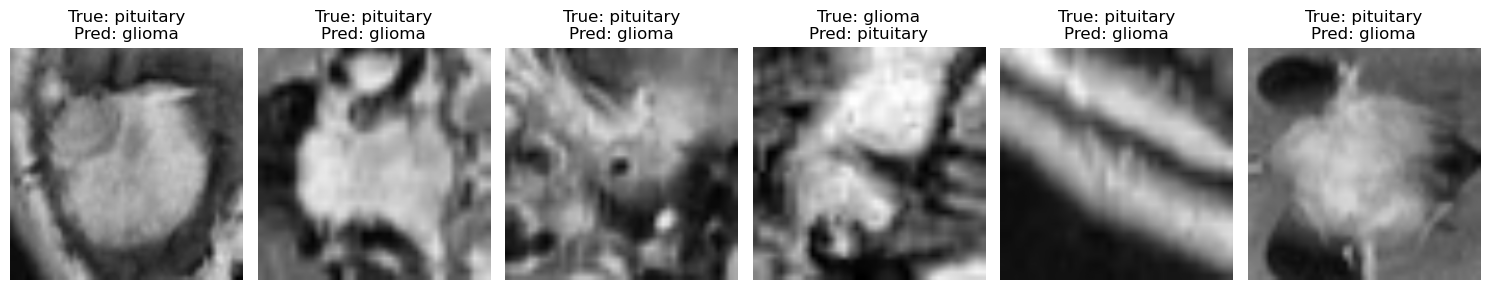

In [28]:
import matplotlib.pyplot as plt

num_samples = len(misclassified)

plt.figure(figsize=(15, 5))

for i, sample in enumerate(misclassified):

    image = (
        sample["image"]
        .permute(1,2,0)
        .numpy()
    )

    true_label = sample["true"]

    pred_label = sample["pred"]

    # Convert labels
    true_name = (
        "pituitary"
        if true_label == 0
        else "glioma"
    )

    pred_name = (
        "pituitary"
        if pred_label == 0
        else "glioma"
    )

    plt.subplot(
        1,
        num_samples,
        i + 1
    )

    plt.imshow(image)

    plt.title(
        f"True: {true_name}\nPred: {pred_name}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

###  Let us add GradCam 

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM

from pytorch_grad_cam.utils.image import show_cam_on_image

In [2]:
from pytorch_grad_cam import GradCAM

print("Grad-CAM installed successfully!")

Grad-CAM installed successfully!


### Recreate The ROI Classifier

In [32]:
import torch
import torch.nn as nn

from torchvision.models import resnet18

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# Rebuild classifier
classification_model = resnet18(
    pretrained=True
)

# Replace classifier head
classification_model.fc = nn.Linear(
    classification_model.fc.in_features,
    2
)

classification_model = classification_model.to(device)

print("Classifier rebuilt")

Classifier rebuilt


### Load Best Saved Weights

In [33]:
classification_model.load_state_dict(

    torch.load(
        "best_roi_classifier.pth",
        map_location=device
    )
)

classification_model.eval()

print("Best classifier loaded")

Best classifier loaded


### THEN Define Grad-CAM Target Layer

In [34]:
target_layers = [
    classification_model.layer4[-1]
]

### Get Validation Batch

In [37]:
batch = next(iter(valid_loader))

images, labels = batch

images = images.to(device)

### Create Grad-CAM Object

In [38]:
from pytorch_grad_cam import GradCAM

cam = GradCAM(

    model=classification_model,

    target_layers=target_layers
)

### Generate Heatmaps

In [39]:
grayscale_cam = cam(
    input_tensor=images
)

print(grayscale_cam.shape)

(16, 224, 224)


### Visualize Grad-CAM

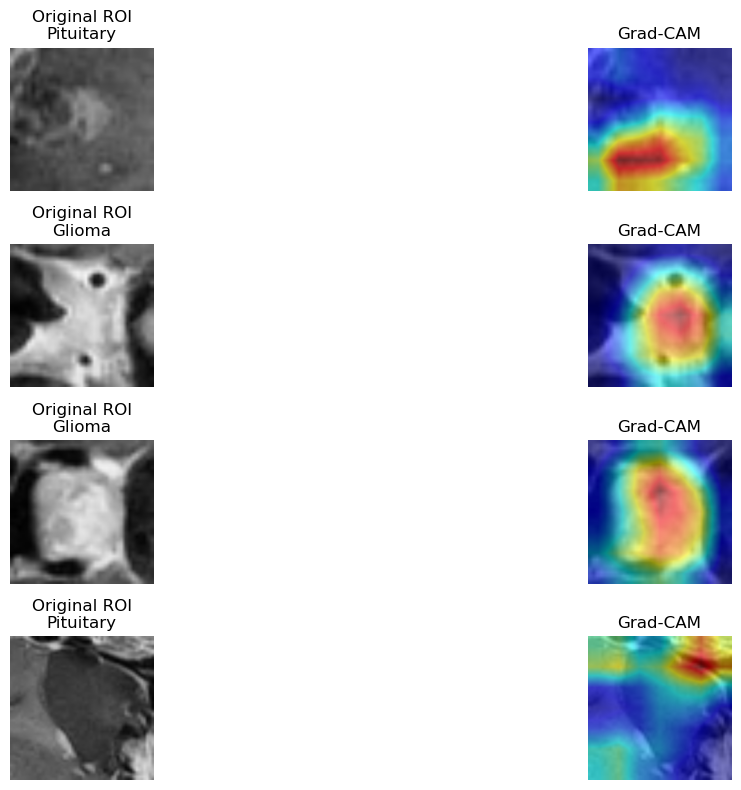

In [40]:
from pytorch_grad_cam.utils.image import show_cam_on_image

import matplotlib.pyplot as plt
import numpy as np

num_samples = 4

plt.figure(figsize=(16,8))

for i in range(num_samples):

    # ---------------- IMAGE ----------------
    image = (
        images[i]
        .cpu()
        .permute(1,2,0)
        .numpy()
    )

    image = np.clip(image, 0, 1)

    # ---------------- HEATMAP ----------------
    heatmap = grayscale_cam[i]

    cam_image = show_cam_on_image(

        image,

        heatmap,

        use_rgb=True
    )

    # ---------------- LABEL ----------------
    true_label = labels[i].item()

    if true_label == 0:

        class_name = "Pituitary"

    else:

        class_name = "Glioma"

    # ---------------- ORIGINAL ----------------
    plt.subplot(num_samples, 2, i*2 + 1)

    plt.imshow(image)

    plt.title(f"Original ROI\n{class_name}")

    plt.axis("off")

    # ---------------- GRAD-CAM ----------------
    plt.subplot(num_samples, 2, i*2 + 2)

    plt.imshow(cam_image)

    plt.title("Grad-CAM")

    plt.axis("off")

plt.tight_layout()

plt.show()

## Segmentation-Guided Brain Tumor Classification Using Refined Tumor ROIs
1. Introduction

Brain tumor subtype classification is a critical task in medical image analysis because different tumor types exhibit distinct biological behaviors, treatment strategies, and prognostic outcomes. However, direct classification from full MRI scans is often challenging because classifiers may learn irrelevant anatomical structures, scanner artifacts, and background information rather than tumor-specific morphology.

To address this limitation, this project implemented a segmentation-guided tumor classification pipeline. Instead of performing classification directly on full MRI images, the workflow first localized and refined tumor regions using a trained Attention U-Net segmentation model. Refined tumor regions of interest (ROIs) were then extracted and used as inputs to a tumor subtype classifier.

The project focused on distinguishing between:

* Pituitary tumors
* Glioma tumors

using morphology-aware tumor ROIs generated from the segmentation pipeline developed in Notebook 1.

### 2. Motivation for Segmentation-Guided Classification

Traditional whole-image classification often suffers from:

* background bias
* irrelevant feature learning
* reduced interpretability
* tumor subtype confusion.

This project hypothesized that:

* refined segmentation masks
* contour-aware ROI extraction
* morphology-focused inputs

would improve tumor subtype discrimination.

The segmentation-guided workflow enabled the classifier to focus primarily on:

* tumor geometry
* contour structure
* infiltrative patterns
* lesion morphology

instead of global MRI appearance.

### Overall Workflow

The complete classification pipeline followed the workflow below:

* MRI Image
   ↓
* Attention U-Net Segmentation
   ↓
* Morphological Refinement
   ↓
* Contour Extraction
   ↓
* Bounding Box ROI Cropping
   ↓
* Tumor ROI Dataset
   ↓
* ResNet18 Classification
   ↓
* Pituitary vs Glioma Prediction

### 4. Dataset Investigation and Class Discovery
4.1 Initial Dataset Assumption

Initially, the dataset appeared to contain only:

* Tumor

* segmentation labels.

However, deeper inspection of the COCO annotation categories revealed hidden subclass information.

### 4.2 COCO Category Analysis

The COCO annotation file contained:

[
 {'id': 0, 'name': 'Tumor'},
 {'id': 1, 'name': '0'},
 {'id': 2, 'name': '1'}
]

Further analysis confirmed that:

* category 1 represented one tumor subtype
* category 2 represented another tumor subtype.

Class distribution analysis showed:

* Tumor Class	 ---------------     * Number of Samples
* Class 1 ---------------------       771
* Class 2	---------------------       730

The dataset was therefore highly balanced.

### 4.3 Visual Tumor Morphology Analysis

Visual inspection of ROI samples suggested:

Class 1

Likely represented:

* Pituitary tumors

Characteristics observed:

* compact structure
* rounded geometry
* symmetric appearance
* smoother boundaries.







Class 2

Likely represented:

* Glioma tumors

Characteristics observed:

* irregular contours
* infiltrative spread
* diffuse structure
* rougher boundaries.

This morphological distinction motivated the use of segmentation-guided classification.

### 5. Loading the Refined Segmentation Model

The best fine-tuned Attention U-Net model from Notebook 1 was loaded and reused as a tumor localization engine.

The segmentation model provided:

* refined tumor masks
* contour-aware localization
* morphology-preserving segmentation outputs.

This avoided retraining segmentation and enabled direct ROI extraction.

### 6. Morphological Refinement Pipeline
6.1 Motivation

Although segmentation predictions localized tumors effectively, some masks still contained:

* noisy white spots
* disconnected regions
* rough contour edges.

To improve ROI quality, morphological refinement was applied before ROI extraction.

### 6.2 Morphological Operations

The following operations were implemented:

Morphological Opening

Used to:

* remove isolated false-positive regions.





 Morphological Closing

Used to:

* smooth tumor boundaries
* improve contour continuity.





 Largest Connected Component Filtering

Used to:

* preserve only the primary tumor region
* suppress noisy disconnected predictions.

### 7. ROI Extraction
7.1 Contour Detection

Contours were extracted from refined segmentation masks using OpenCV contour analysis.

The largest tumor contour was selected for ROI extraction.

### 7.2 Bounding Box Cropping

For each tumor:

* bounding boxes were computed
* tumor regions were cropped
* resized to classification input dimensions.

Final ROI size:

224×224

### 7.3 ROI Dataset Generation

The segmentation-guided pipeline successfully generated:

1500/1502

tumor ROIs.

This indicated:

* strong segmentation stability
* reliable contour extraction
* robust ROI generation.

### 8. ROI-Based Classification
8.1 Classification Model

The classifier utilized ResNet18.

Reasons for selection:

* lightweight architecture
* stable training behavior
* strong transfer learning performance
* suitability for medical imaging tasks.

### 8.2 Transfer Learning

A pretrained ResNet18 model was loaded and fine-tuned for binary tumor subtype classification.

The final fully connected layer was replaced with:

two output neurons:
* pituitary
* glioma.

### 8.3 Data Augmentation

Training augmentation included:

* random horizontal flipping
* random rotation
* resizing
* tensor conversion.

These augmentations improved:

* generalization
* robustness
* morphology learning.

### 9. Model Training
9.1 Training Configuration

The classifier was trained using:

* Cross Entropy Loss
* Adam optimizer.

Learning rate:

10
−4

### 9.2 Validation Monitoring

Validation accuracy was monitored during training.

Best validation accuracy achieved:

* 98%

The best-performing classifier checkpoint was saved automatically.

### 10. Classification Results
10.1 Final Validation Accuracy

The best classifier achieved:

* 98%

validation accuracy.

# 10.2 Confusion Matrix

|  | Predicted Pituitary | Predicted Glioma |
|---|---|---|
| Actual Pituitary | 149 | 5 |
| Actual Glioma | 1 | 145 |

## Interpretation

### Pituitary Tumors
- Correctly classified: 149
- Misclassified as glioma: 5

This indicates that the classifier effectively identified most pituitary tumors with minimal confusion.

---

### Glioma Tumors
- Correctly classified: 145
- Misclassified as pituitary: 1

This demonstrates extremely strong glioma recognition performance.

---

## Overall Observation

The confusion matrix shows:
- strong subtype discrimination
- minimal inter-class confusion
- balanced classification performance

The segmentation-guided ROI extraction significantly improved morphology-aware tumor classification.

### 11. Classification Report

| Metric | Pituitary | Glioma |
|---|---|---|
| Precision | 0.99 | 0.97 |
| Recall | 0.97 | 0.99 |
| F1-score | 0.98 | 0.98 |

The classifier demonstrated:
- Balanced performance
- Strong subtype discrimination
- Minimal inter-class confusion

### Key Observations
12.1 Segmentation Improved Class Separability

Compared to whole MRI classification, segmentation-guided ROI extraction:

* emphasized tumor morphology
* reduced background distractions
* improved contour awareness.

### 12.2 Morphological Features Became Highly Informative

The classifier appeared to learn:

* contour smoothness
* infiltrative behavior
* geometric structure
* tumor symmetry.

### 12.3 Glioma Detection Was Especially Strong

Glioma recall reached:

0.99

indicating that:

* irregular infiltrative structures
were effectively captured by the segmentation-guided workflow.

### 13. Explainability and Grad-CAM

To improve model interpretability, Grad-CAM visualization was introduced.

Grad-CAM enabled visualization of:

* classifier attention regions
* morphology-sensitive areas
* tumor-focused activation maps.

The explainability stage aimed to verify that the classifier focused on:

* tumor boundaries
* contour irregularities
* infiltrative regions

rather than irrelevant background regions.

### 14. Challenges Encountered
1. Hidden Dataset Subclasses
Challenge:
Tumor subclasses were initially hidden as numeric labels.
Solution:
* Performed COCO annotation analysis and class distribution inspection.



2. ROI Extraction Stability
Challenge:
Some segmentation masks contained noisy contour regions.



Solution:
Applied:
* morphological opening
* morphological closing
* connected component filtering.






3. Kernel Restarts
Challenge:
Notebook resets caused loss of:
* loaders
* datasets
* transforms
* model variables.



Solution:
* Rebuilt the workflow modularly using:
* checkpoints
* saved ROIs
* reproducible dataset reconstruction.






4. Best Model Evaluation
Challenge:
* Initial evaluation mistakenly used the final epoch instead of the best checkpoint.
Solution:
* Reloaded the saved best classifier checkpoint before evaluation.

## 15. Conclusion

This project successfully demonstrated a complete segmentation-guided tumor classification workflow for brain MRI analysis.

The integration of:

* Attention U-Net segmentation
* contour refinement
* morphological post-processing
* ROI extraction
* ResNet18 classification

produced highly accurate tumor subtype discrimination.

The segmentation-guided workflow significantly improved:

* morphology awareness
* contour sensitivity
* subtype separability

while reducing:

* background bias
* irrelevant feature learning.

The final system achieved:

* strong pituitary-glioma discrimination
* excellent validation accuracy
* highly interpretable tumor-focused classification behavior.

This project demonstrates the potential of combining:

semantic segmentation
with
morphology-aware classification

for more clinically meaningful medical imaging AI systems.